# Feature Selection & Dimensionality Optimization

In [1]:
# imports 

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from catboost import CatBoostClassifier

import shap 


In [6]:
# Create Engineered Dataset

from src.preprocessing import PreprocessConfig, preprocess_train_test
from src.features import FeatureConfig, engineer_train_test_features

# Load raw data
TRAIN_PATH = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Train.csv"
TEST_PATH  = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Test.csv"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)

# Initiliaze configs
pre_cfg = PreprocessConfig(
    id_col="ID",
    target_col="Target"
)

feat_cfg = FeatureConfig(
    id_col="ID",
    target_col="Target"
)

#run preprocessing
train_clean, test_clean = preprocess_train_test(
    train_raw,
    test_raw,
    pre_cfg,
    for_model="lightgbm"  # We use "lightgbm" here because the output is fully numeric, which is easier for: correlation analysis, SHAP & feature importance
)

# Run feature engineering
train_fe, test_fe = engineer_train_test_features(
    train_clean,
    test_clean,
    feat_cfg,
    collapse_rare_for_non_catboost=True
)

In [7]:
# Save the Engineered Dataset

import os

os.makedirs("data/processed", exist_ok=True)

train_fe.to_csv("data/processed/train_engineered.csv", index=False)
test_fe.to_csv("data/processed/test_engineered.csv", index=False)

print("Engineered datasets saved.")

Engineered datasets saved.


In [8]:
# Load feature selection

train_df = pd.read_csv("data/processed/train_engineered.csv")

TARGET = "Target"
ID = "ID"

X = train_df.drop(columns=[TARGET, ID])
y = train_df[TARGET]

feature_names = X.columns.tolist()

print("Feature count:", len(feature_names))

Feature count: 117


In [9]:
# Cross-Validation Setup

N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

Train Baseline Models to Collect Feature Importance. We collect feature importance across folds to measure stability.

In [13]:
X.dtypes.value_counts()

float64    55
str        44
int64      18
Name: count, dtype: int64

In [14]:
bad_cols = X.select_dtypes(include=["object"]).columns
print(len(bad_cols))
print(bad_cols)

C:\Users\otsyu\AppData\Local\Temp\ipykernel_14024\1907510790.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  bad_cols = X.select_dtypes(include=["object"]).columns


44
Index(['country', 'attitude_stable_business_environment',
       'attitude_worried_shutdown', 'compliance_income_tax',
       'perception_insurance_doesnt_cover_losses',
       'perception_cannot_afford_insurance', 'motor_vehicle_insurance',
       'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone',
       'owner_sex', 'offers_credit_to_customers',
       'attitude_satisfied_with_achievement', 'has_credit_card',
       'keeps_financial_records',
       'perception_insurance_companies_dont_insure_businesses_like_yours',
       'perception_insurance_important', 'has_insurance',
       'covid_essential_service', 'attitude_more_successful_next_year',
       'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account',
       'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock',
       'medical_insurance', 'funeral_insurance', 'motivation_make_more_money',
       'uses_friends_family_savings', 'uses_informal_lender',
       'business_age_bucket', '

In [15]:
cat_cols = X.select_dtypes(include=["object"]).columns

for col in cat_cols:
    X[col] = X[col].astype("category")

C:\Users\otsyu\AppData\Local\Temp\ipykernel_14024\88062776.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns


In [16]:
X.dtypes.value_counts()

float64     55
int64       18
category    10
category     9
category     7
category     2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

 **LightGBM feature importance**

In [ ]:


# Identify categorical columns
cat_cols = X.select_dtypes(include=["category"]).columns.tolist()

lgb_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=1200,
        learning_rate=0.02,
        num_leaves=128,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="multi_logloss",
        categorical_feature=cat_cols
    )

    lgb_importances.append(model.feature_importances_)

# aggregate & Convert to dataframe

lgb_importances = np.array(lgb_importances)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_importances.mean(axis=0)
}).sort_values("importance", ascending=False)

importance_df.head(30)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071309 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4085
[LightGBM] [Info] Number of data points in the train set: 7694, number of used features: 114
[LightGBM] [Info] Start training from score -3.018607
[LightGBM] [Info] Start training from score -0.426214
[LightGBM] [Info] Start training from score -1.210144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

,feature,importance
1,owner_age,32324.2
88,expenses_to_personal_income,28697.8
87,turnover_to_personal_income,27434.8
7,personal_income,22656.6
85,expense_ratio,22323.0
8,business_expenses,22245.4
84,margin_proxy,19756.6
43,business_age_total_months,18236.0
9,business_turnover,17840.4
86,turnover_to_expenses,17723.6


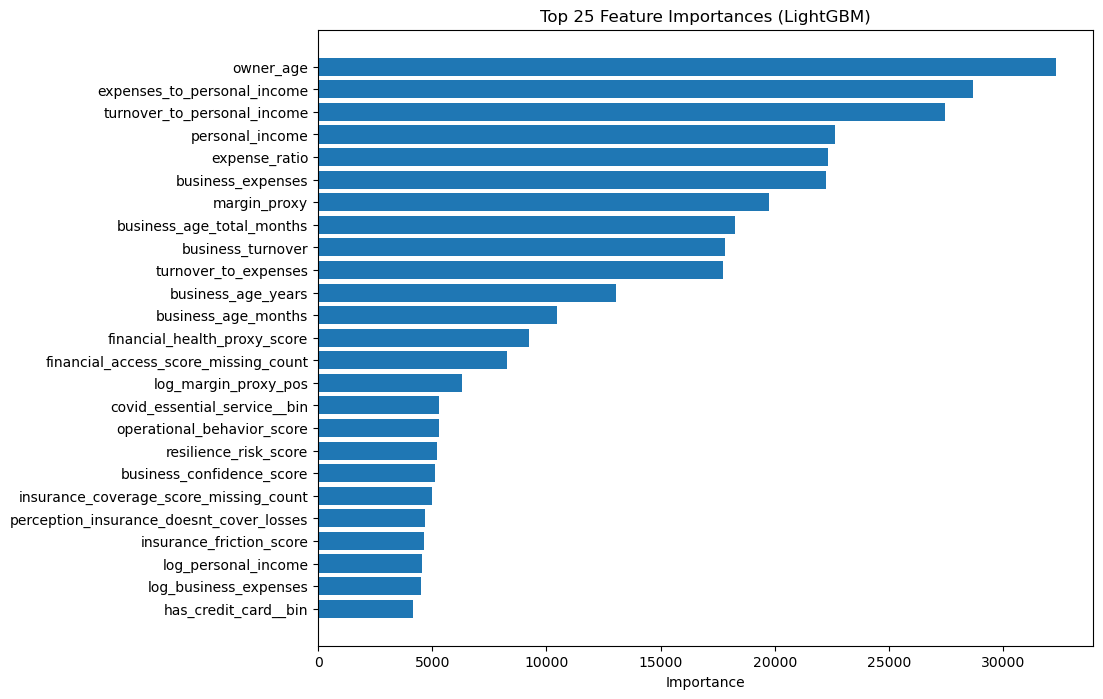

In [21]:
# Visualize top features 

import matplotlib.pyplot as plt

top_n = 25

plt.figure(figsize=(10,8))

plt.barh(
    importance_df.head(top_n)["feature"][::-1],
    importance_df.head(top_n)["importance"][::-1]
)

plt.title("Top 25 Feature Importances (LightGBM)")
plt.xlabel("Importance")
plt.show()

In [22]:
# reduce feature set

top_features = importance_df.head(80)["feature"].tolist()

X_reduced = X[top_features]

print("Original features:", X.shape[1])
print("Reduced features:", X_reduced.shape[1])

Original features: 117
Reduced features: 80


**CatBoost Feature Importance**

In [26]:
cat_importances = []

cat_cols = X.select_dtypes(include=["category"]).columns.tolist()

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.03,
        depth=8,
        loss_function="MultiClass",
        eval_metric="TotalF1",
        verbose=False,
        random_seed=42
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_cols   # ← IMPORTANT
    )

    cat_importances.append(model.get_feature_importance())

In [27]:
# Aggregate feature Importance

cat_importances = np.array(cat_importances)

cat_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": cat_importances.mean(axis=0)
}).sort_values("importance", ascending=False)

cat_importance_df.head(30)

,feature,importance
33,funeral_insurance,26.528373
35,uses_friends_family_savings,3.612359
27,has_loan_account,3.592212
18,has_credit_card,3.194612
29,has_debit_card,2.935347
22,has_insurance,2.708297
47,has_credit_card__bin,2.426901
107,country_x_has_loan_account,1.993100
32,medical_insurance,1.933348
11,motor_vehicle_insurance,1.710476


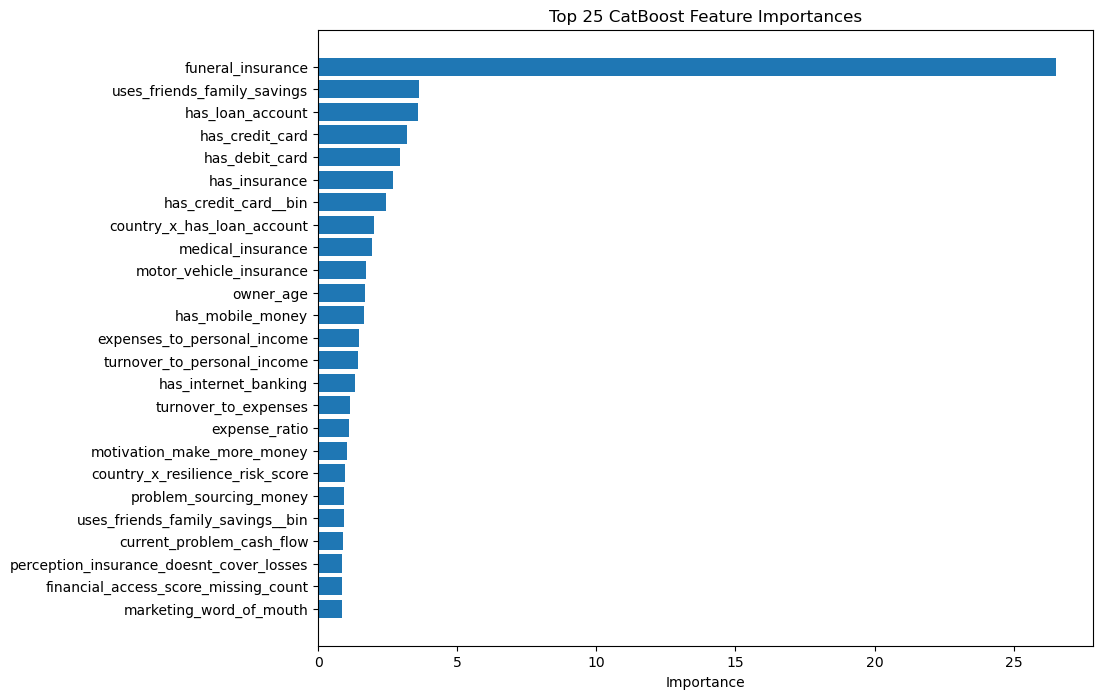

In [28]:
# Plot feature importance

top_n = 25

plt.figure(figsize=(10,8))

plt.barh(
    cat_importance_df.head(top_n)["feature"][::-1],
    cat_importance_df.head(top_n)["importance"][::-1]
)

plt.title("Top 25 CatBoost Feature Importances")
plt.xlabel("Importance")

plt.show()